# Healthcare Analysis: Cost Regression, Readmission Risk, and Production-Style Governance

**The problem.** Healthcare payers and provider networks live at the intersection of two very different decision problems: forecasting **expected patient cost** for budgeting and risk adjustment, and flagging **readmission risk** to target costly interventions. A model that does one well and the other poorly under-delivers on both, because the economics are tied: intervention decisions depend on expected cost *and* readmission probability *and* calibrated uncertainty *and* fairness across demographic subgroups. The question this notebook answers: **what does an end-to-end healthcare modelling workflow look like when it is built for governance and deployment from day one, not as a retrofit?**

**The approach.** Production-style, dual-task workflow — not a toy demo — covering:

- Data quality and validation, deep exploratory analysis with statistical signal checks.
- Dual-task modelling: **regression** for `healthcare_cost`, **classification** for `readmission`, both cross-validated and benchmarked across model families.
- Calibration and **cost-aware threshold** optimisation driven by explicit FP/FN business costs.
- Interpretability stack: permutation importance, SHAP (with graceful fallback), PDP/ICE, and subgroup error analysis.
- Hyperparameter search with **bootstrap confidence intervals** on metrics.
- **Temporal validation** and PSI-based drift monitoring.
- **Fairness audit** across demographic and plan subgroups.
- **Clinical decision curve analysis** (Vickers & Elkin) for net-benefit framing against treat-all / treat-none.
- Model persistence + end-to-end single-patient inference demo.
- Causal **uplift** modelling (simulated RCT, T-learner, Qini) for intervention targeting.
- **Survival / time-to-readmission** analysis (KM, Cox PH).
- **Auto-generated model card** (JSON + Markdown governance artifact).

**Audience.** Healthcare data scientists, actuarial and HEOR teams, clinical informatics reviewers, and the model-risk partners who sign off the release.

## 1. Setup and Reproducibility


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import randint, uniform, loguniform
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
)
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

print("Environment ready.")


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Environment ready.


## 2. Data Loading

The notebook tries to load a real dataset first. If none is found, it generates a realistic synthetic dataset so the full workflow still runs.


In [2]:
def make_synthetic_healthcare_data(n: int = 6000, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    age = rng.integers(18, 90, size=n)
    gender = rng.choice(["Female", "Male"], size=n, p=[0.52, 0.48])
    smoker = rng.choice(["No", "Yes"], size=n, p=[0.78, 0.22])
    region = rng.choice(["North", "South", "East", "West"], size=n)
    plan_tier = rng.choice(["Basic", "Standard", "Premium"], size=n, p=[0.45, 0.40, 0.15])

    bmi = np.clip(rng.normal(27.5, 5.3, size=n), 15, 55)
    blood_pressure = np.clip(rng.normal(122, 16, size=n) + (age - 50) * 0.15, 80, 220)
    cholesterol = np.clip(rng.normal(195, 38, size=n) + (age - 50) * 0.6, 100, 420)

    chronic_conditions = rng.poisson(1.1 + (age > 60) * 0.7 + (smoker == "Yes") * 0.5)
    chronic_conditions = np.clip(chronic_conditions, 0, 7)

    visits_last_year = np.clip(
        rng.poisson(2.5 + chronic_conditions * 0.9 + (smoker == "Yes") * 0.4),
        0,
        20,
    )

    base_cost = 400 + age * 18 + np.maximum(0, bmi - 25) * 60
    risk_cost = (
        (smoker == "Yes") * 1800
        + chronic_conditions * 950
        + visits_last_year * 180
        + np.maximum(0, blood_pressure - 130) * 14
        + np.maximum(0, cholesterol - 210) * 8
    )

    region_factor = pd.Series(region).map({"North": 1.02, "South": 0.98, "East": 1.05, "West": 0.95}).values
    tier_factor = pd.Series(plan_tier).map({"Basic": 0.92, "Standard": 1.0, "Premium": 1.12}).values

    noise = rng.normal(0, 1100, size=n)
    healthcare_cost = np.clip((base_cost + risk_cost + noise) * region_factor * tier_factor, 250, None)

    logit = (
        -3.2
        + 0.018 * (age - 50)
        + 0.035 * (bmi - 27)
        + 0.012 * (blood_pressure - 120)
        + 0.009 * (cholesterol - 190)
        + 0.38 * chronic_conditions
        + 0.11 * visits_last_year
        + 0.8 * (smoker == "Yes")
    )
    p_readmit = 1 / (1 + np.exp(-logit))
    readmission = rng.binomial(1, np.clip(p_readmit, 0.01, 0.95), size=n)

    df = pd.DataFrame(
        {
            "age": age,
            "gender": gender,
            "smoker": smoker,
            "region": region,
            "plan_tier": plan_tier,
            "bmi": bmi.round(2),
            "blood_pressure": blood_pressure.round(1),
            "cholesterol": cholesterol.round(1),
            "chronic_conditions": chronic_conditions,
            "visits_last_year": visits_last_year,
            "readmission": readmission,
            "healthcare_cost": healthcare_cost.round(2),
        }
    )

    # Inject realistic missingness
    missing_rates = {
        "bmi": 0.06,
        "blood_pressure": 0.05,
        "cholesterol": 0.07,
        "plan_tier": 0.03,
    }
    for col, rate in missing_rates.items():
        mask = rng.random(n) < rate
        df.loc[mask, col] = np.nan

    return df


candidate_paths = [
    Path("data/healthcare.csv"),
    Path("datasets/healthcare.csv"),
    Path("notebooks/data/healthcare.csv"),
]

existing_path = next((p for p in candidate_paths if p.exists()), None)

if existing_path is not None:
    df = pd.read_csv(existing_path)
    data_source = f"loaded from {existing_path}"
else:
    df = make_synthetic_healthcare_data(n=6000, random_state=42)
    data_source = "synthetic generator"

print(f"Rows: {len(df):,} | Columns: {df.shape[1]} | Source: {data_source}")
print(df.head())


Rows: 6,000 | Columns: 12 | Source: synthetic generator
   age  gender smoker region plan_tier    bmi  blood_pressure  cholesterol  chronic_conditions  visits_last_year  readmission  \
0   24    Male    Yes  North     Basic  26.42           118.8        192.2                   0                 2            0   
1   73    Male     No  South  Standard  28.58           112.8        231.8                   0                 4            0   
2   65  Female     No   West   Premium    NaN           141.3        203.7                   1                 2            0   
3   49    Male     No  North     Basic  29.62           108.2        186.4                   0                 2            0   
4   49  Female     No  North   Premium  30.76            93.5        116.0                   2                 7            0   

   healthcare_cost  
0          4972.66  
1          1105.62  
2          2378.28  
3          2130.40  
4          5964.51  


## 3. Data Quality Audit


In [3]:
def quality_report(data: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "missing_n": data.isna().sum(),
            "missing_pct": (data.isna().mean() * 100).round(2),
            "n_unique": data.nunique(dropna=True),
        }
    )
    return out.sort_values(["missing_pct", "n_unique"], ascending=[False, False])

report = quality_report(df)
display(report)

print("\nPotential duplicates:", int(df.duplicated().sum()))

# Basic constraints sanity checks
constraints = {
    "age": (0, 120),
    "bmi": (10, 80),
    "blood_pressure": (60, 260),
    "cholesterol": (70, 500),
    "healthcare_cost": (0, np.inf),
}

violations = {}
for col, (low, high) in constraints.items():
    if col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce")
        n_bad = int(((s < low) | (s > high)).sum())
        violations[col] = n_bad

print("Constraint violations:", violations)


,dtype,missing_n,missing_pct,n_unique
cholesterol,float64,426,7.10,1617
bmi,float64,324,5.40,1997
blood_pressure,float64,283,4.72,797
plan_tier,str,190,3.17,3
healthcare_cost,float64,0,0.00,5862
age,int64,0,0.00,72
visits_last_year,int64,0,0.00,15
chronic_conditions,int64,0,0.00,8
region,str,0,0.00,4
gender,str,0,0.00,2



Potential duplicates: 0
Constraint violations: {'age': 0, 'bmi': 0, 'blood_pressure': 0, 'cholesterol': 0, 'healthcare_cost': 0}


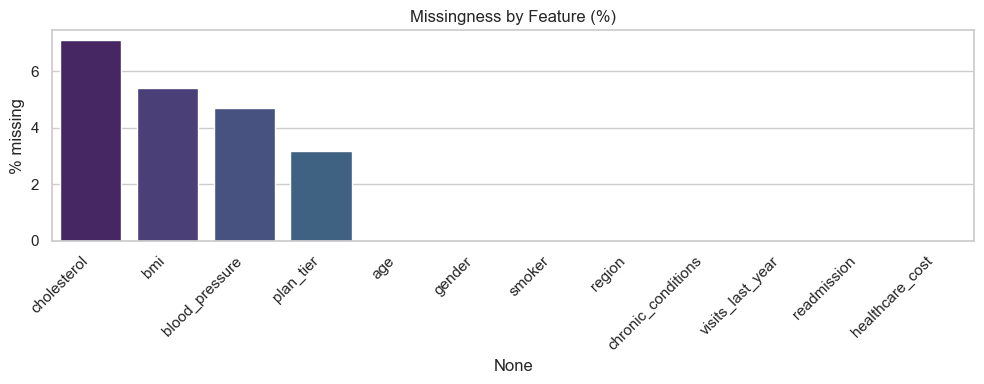

In [4]:
# Missingness visualization
plt.figure(figsize=(10, 4))
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
sns.barplot(x=missing_pct.index, y=missing_pct.values, hue=missing_pct.index, legend=False, palette="viridis")
plt.title("Missingness by Feature (%)")
plt.ylabel("% missing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Exploratory Data Analysis


In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['age', 'bmi', 'blood_pressure', 'cholesterol', 'chronic_conditions', 'visits_last_year', 'readmission', 'healthcare_cost']
Categorical columns: ['gender', 'smoker', 'region', 'plan_tier']


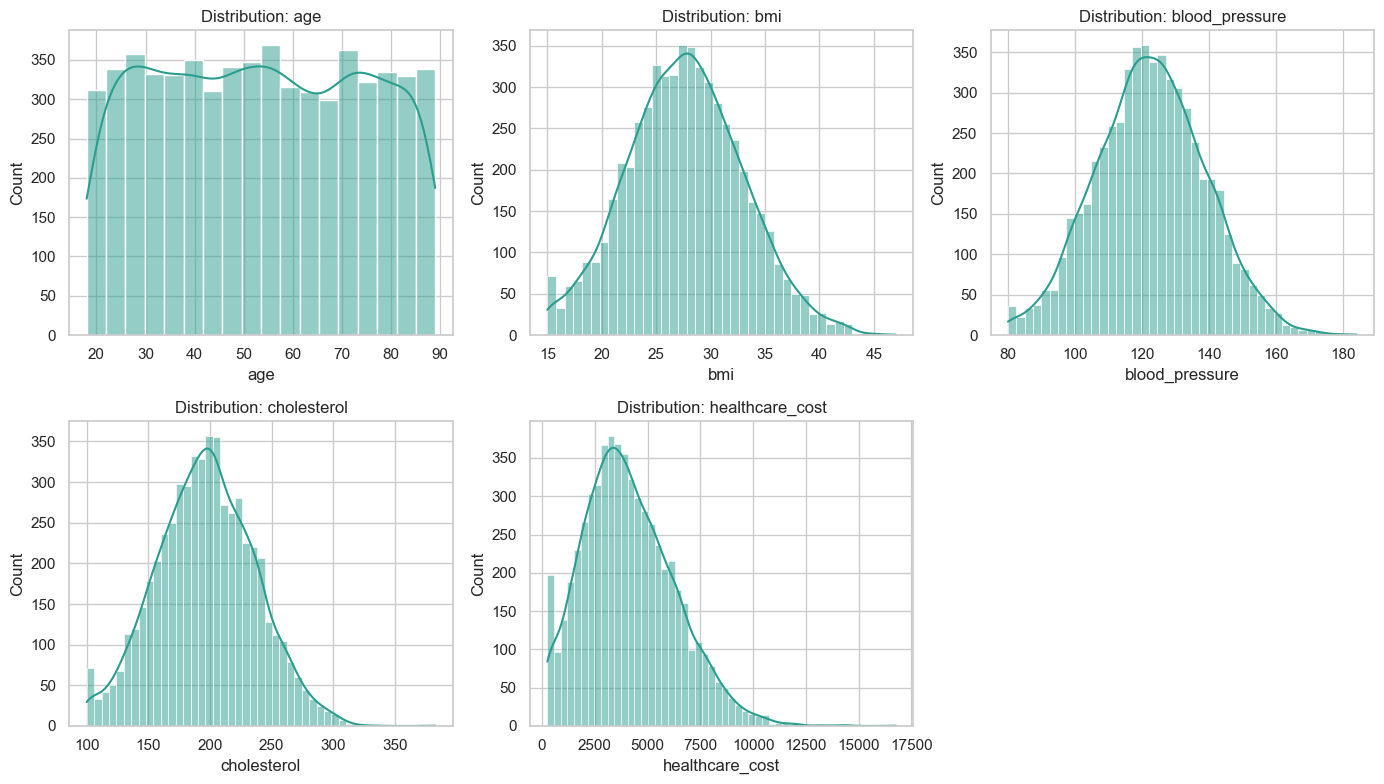

In [6]:
# Distribution diagnostics for key continuous variables
key_num = [c for c in ["age", "bmi", "blood_pressure", "cholesterol", "healthcare_cost"] if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(key_num):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2a9d8f")
    axes[i].set_title(f"Distribution: {col}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


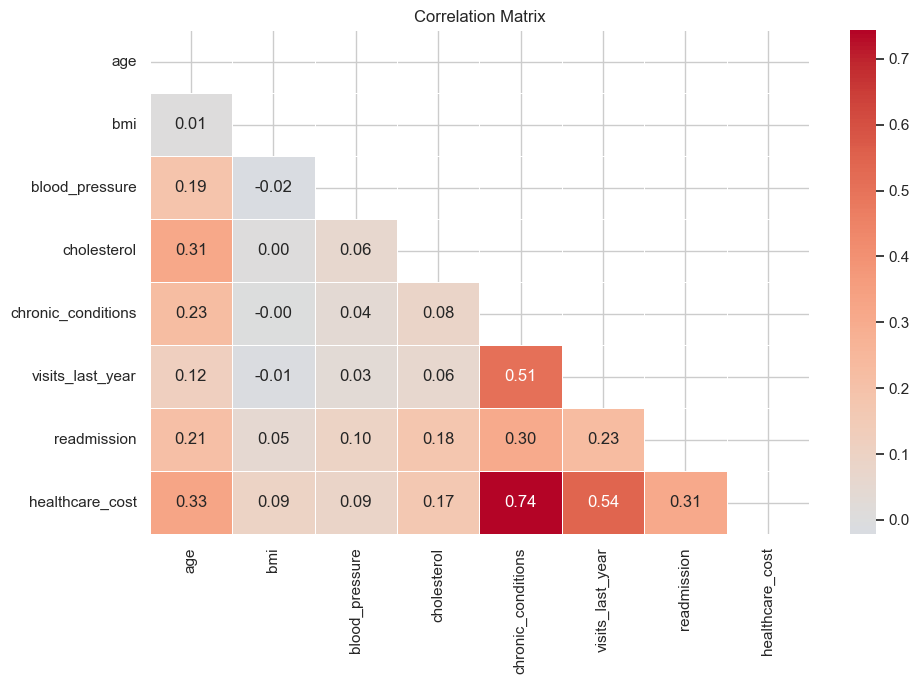

In [7]:
# Correlation matrix (numeric only)
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


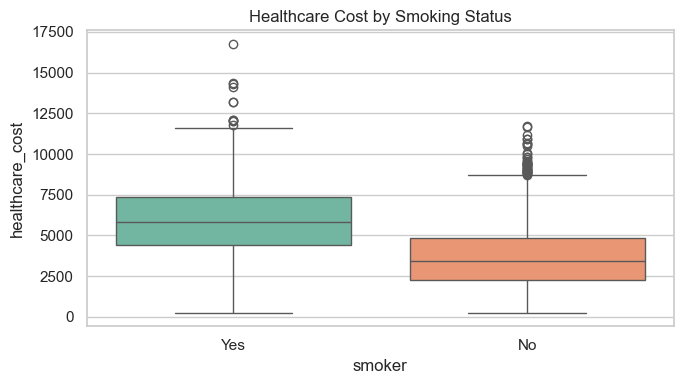

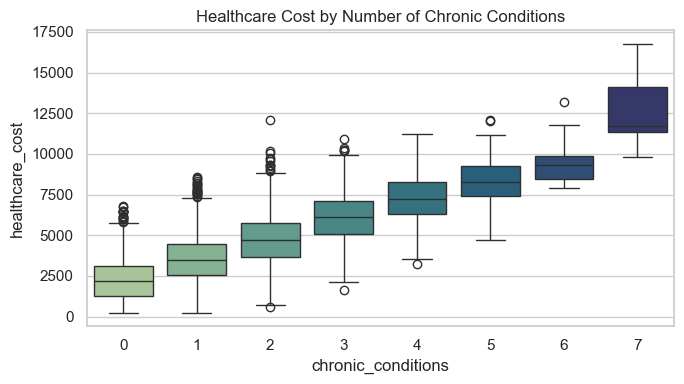

smoker
Yes    29.46
No     14.48
Name: readmission_rate_pct, dtype: float64

In [8]:
# Outcome-focused plots
if {"smoker", "healthcare_cost"}.issubset(df.columns):
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="smoker", y="healthcare_cost", hue="smoker", legend=False, palette="Set2")
    plt.title("Healthcare Cost by Smoking Status")
    plt.tight_layout()
    plt.show()

if {"chronic_conditions", "healthcare_cost"}.issubset(df.columns):
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="chronic_conditions", y="healthcare_cost", hue="chronic_conditions", legend=False, palette="crest")
    plt.title("Healthcare Cost by Number of Chronic Conditions")
    plt.tight_layout()
    plt.show()

if {"readmission", "smoker"}.issubset(df.columns):
    readmit_rate = df.groupby("smoker", dropna=False)["readmission"].mean().sort_values(ascending=False)
    display((readmit_rate * 100).round(2).rename("readmission_rate_pct"))


In [9]:
# Lightweight statistical tests for signal validation
if {"smoker", "healthcare_cost"}.issubset(df.columns):
    g0 = df.loc[df["smoker"] == "No", "healthcare_cost"].dropna()
    g1 = df.loc[df["smoker"] == "Yes", "healthcare_cost"].dropna()
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    print(f"Mann-Whitney test (cost by smoker): U={u_stat:.1f}, p-value={p_val:.3e}")

if {"smoker", "readmission"}.issubset(df.columns):
    cont = pd.crosstab(df["smoker"], df["readmission"])
    chi2, p_val, dof, _ = stats.chi2_contingency(cont)
    print(f"Chi-square (smoker vs readmission): chi2={chi2:.2f}, dof={dof}, p-value={p_val:.3e}")


Mann-Whitney test (cost by smoker): U=1243751.0, p-value=2.121e-232
Chi-square (smoker vs readmission): chi2=154.92, dof=1, p-value=1.460e-35


## 5. Train/Test Design

We model two targets:
- `healthcare_cost` (regression),
- `readmission` (binary classification).


In [10]:
required_targets = ["healthcare_cost", "readmission"]
missing_targets = [c for c in required_targets if c not in df.columns]
if missing_targets:
    raise ValueError(f"Missing required targets: {missing_targets}")

X = df.drop(columns=required_targets)
y_reg = df["healthcare_cost"].copy()
y_clf = df["readmission"].astype(int).copy()

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf,
)

num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Positive class rate (train): {y_clf_train.mean():.3f}")
print(f"Numeric features: {len(num_features)} | Categorical features: {len(cat_features)}")


Train size: 4,800 | Test size: 1,200
Positive class rate (train): 0.177
Numeric features: 6 | Categorical features: 4


In [11]:
numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_features),
        ("cat", categorical_preprocess, cat_features),
    ],
    remainder="drop",
)

print("Preprocessing pipeline ready.")


Preprocessing pipeline ready.


## 6. Regression Modeling (`healthcare_cost`)

Benchmark multiple models using cross-validation before selecting a final model.


In [12]:
reg_models = {
    "elastic_net": ElasticNet(alpha=0.03, l1_ratio=0.2, random_state=42),
    "random_forest": RandomForestRegressor(
        n_estimators=450,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "hist_gb": HistGradientBoostingRegressor(
        learning_rate=0.06,
        max_depth=6,
        max_iter=420,
        min_samples_leaf=25,
        random_state=42,
    ),
}

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

reg_results = []
for name, model in reg_models.items():
    pipe = Pipeline([
        ("prep", clone(preprocessor)),
        ("model", model),
    ])
    scores = cross_validate(
        pipe,
        X_train,
        y_reg_train,
        cv=cv_reg,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
    )
    reg_results.append(
        {
            "model": name,
            "cv_mae": -scores["test_mae"].mean(),
            "cv_rmse": -scores["test_rmse"].mean(),
            "cv_r2": scores["test_r2"].mean(),
        }
    )

reg_cv_df = pd.DataFrame(reg_results).sort_values("cv_rmse")
display(reg_cv_df)

best_reg_name = reg_cv_df.iloc[0]["model"]
print("Best regression model by CV RMSE:", best_reg_name)


,model,cv_mae,cv_rmse,cv_r2
0,elastic_net,878.452628,1097.619526,0.744361
1,random_forest,917.919003,1148.389467,0.720265
2,hist_gb,927.685667,1159.311118,0.714929


Best regression model by CV RMSE: elastic_net


In [13]:
best_reg = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", reg_models[best_reg_name]),
])

best_reg.fit(X_train, y_reg_train)
reg_pred = best_reg.predict(X_test)

reg_metrics = {
    "test_mae": mean_absolute_error(y_reg_test, reg_pred),
    "test_rmse": root_mean_squared_error(y_reg_test, reg_pred),
    "test_r2": r2_score(y_reg_test, reg_pred),
}

print("Regression holdout metrics:")
for k, v in reg_metrics.items():
    print(f"  {k}: {v:.4f}")


Regression holdout metrics:
  test_mae: 851.0111
  test_rmse: 1071.1158
  test_r2: 0.7474


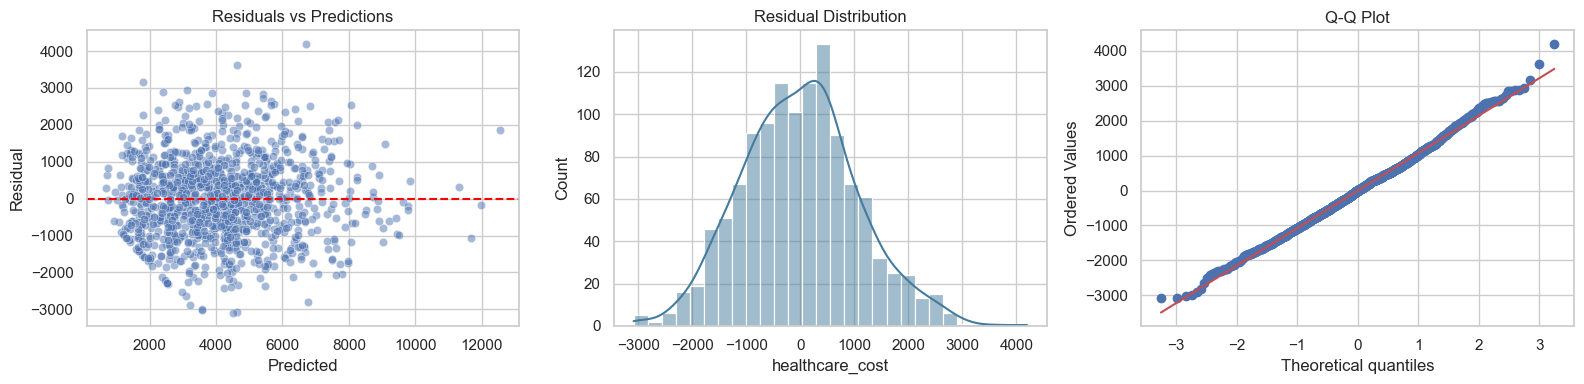

In [14]:
# Residual diagnostics
residuals = y_reg_test - reg_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(x=reg_pred, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Predictions")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")

sns.histplot(residuals, kde=True, ax=axes[1], color="#457b9d")
axes[1].set_title("Residual Distribution")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()


## 7. Classification Modeling (`readmission`)

Benchmark classifiers with stratified CV and optimize decision threshold using business cost.


In [15]:
clf_models = {
    "logistic": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "hist_gb": HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_depth=6,
        max_iter=320,
        min_samples_leaf=25,
        random_state=42,
    ),
}

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_results = []
for name, model in clf_models.items():
    pipe = Pipeline([
        ("prep", clone(preprocessor)),
        ("model", model),
    ])
    scores = cross_validate(
        pipe,
        X_train,
        y_clf_train,
        cv=cv_clf,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "f1": "f1",
        },
        n_jobs=-1,
    )
    clf_results.append(
        {
            "model": name,
            "cv_roc_auc": scores["test_roc_auc"].mean(),
            "cv_pr_auc": scores["test_pr_auc"].mean(),
            "cv_f1": scores["test_f1"].mean(),
        }
    )

clf_cv_df = pd.DataFrame(clf_results).sort_values("cv_roc_auc", ascending=False)
display(clf_cv_df)

best_clf_name = clf_cv_df.iloc[0]["model"]
print("Best classifier by CV ROC-AUC:", best_clf_name)


,model,cv_roc_auc,cv_pr_auc,cv_f1
0,logistic,0.772170,0.448933,0.461404
1,random_forest,0.745075,0.398677,0.308455
2,hist_gb,0.725814,0.385650,0.297174


Best classifier by CV ROC-AUC: logistic


In [16]:
# Fit best classifier and calibrate probabilities
base_best_clf = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", clf_models[best_clf_name]),
])

calibrated_clf = CalibratedClassifierCV(base_best_clf, method="isotonic", cv=3)
calibrated_clf.fit(X_train, y_clf_train)

proba_test = calibrated_clf.predict_proba(X_test)[:, 1]

print("Holdout discrimination:")
print(f"  ROC-AUC: {roc_auc_score(y_clf_test, proba_test):.4f}")
print(f"  PR-AUC:  {average_precision_score(y_clf_test, proba_test):.4f}")


Holdout discrimination:
  ROC-AUC: 0.7604
  PR-AUC:  0.4558


In [17]:
def evaluate_thresholds(y_true: pd.Series, probs: np.ndarray, c_fp: float = 1.0, c_fn: float = 5.0) -> pd.DataFrame:
    rows = []
    for t in np.linspace(0.05, 0.95, 91):
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        cost = c_fp * fp + c_fn * fn
        rows.append(
            {
                "threshold": t,
                "precision": precision_score(y_true, preds, zero_division=0),
                "recall": recall_score(y_true, preds, zero_division=0),
                "f1": f1_score(y_true, preds, zero_division=0),
                "cost_per_patient": cost / len(y_true),
            }
        )
    return pd.DataFrame(rows)

C_FP = 1.0
C_FN = 6.0
threshold_df = evaluate_thresholds(y_clf_test, proba_test, c_fp=C_FP, c_fn=C_FN)
best_t_row = threshold_df.loc[threshold_df["cost_per_patient"].idxmin()]
opt_t = float(best_t_row["threshold"])

print("Cost-sensitive threshold optimization")
print(f"  C_FP={C_FP}, C_FN={C_FN}")
print(f"  Optimal threshold={opt_t:.2f}")
print(best_t_row)


Cost-sensitive threshold optimization
  C_FP=1.0, C_FN=6.0
  Optimal threshold=0.18
threshold           0.180000
precision           0.337931
recall              0.693396
f1                  0.454405
cost_per_patient    0.565000
Name: 13, dtype: float64


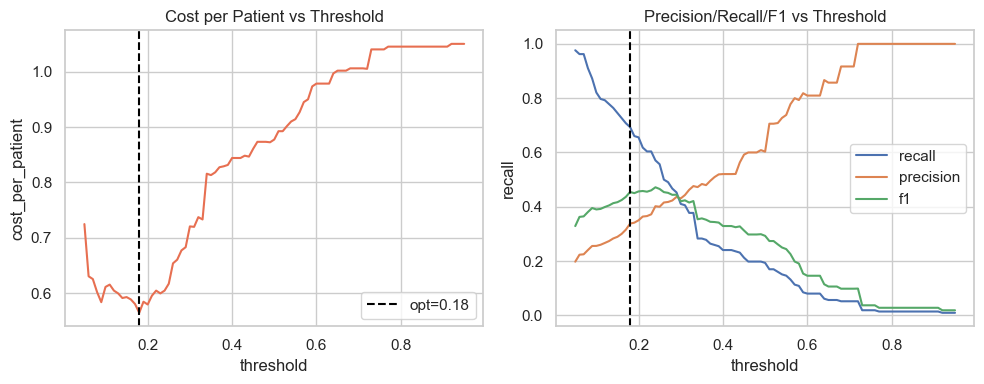

              precision    recall  f1-score   support

           0      0.915     0.709     0.799       988
           1      0.338     0.693     0.454       212

    accuracy                          0.706      1200
   macro avg      0.626     0.701     0.627      1200
weighted avg      0.813     0.706     0.738      1200



In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.lineplot(data=threshold_df, x="threshold", y="cost_per_patient", color="#e76f51")
plt.axvline(opt_t, color="black", linestyle="--", label=f"opt={opt_t:.2f}")
plt.title("Cost per Patient vs Threshold")
plt.legend()

plt.subplot(1, 2, 2)
sns.lineplot(data=threshold_df, x="threshold", y="recall", label="recall")
sns.lineplot(data=threshold_df, x="threshold", y="precision", label="precision")
sns.lineplot(data=threshold_df, x="threshold", y="f1", label="f1")
plt.axvline(opt_t, color="black", linestyle="--")
plt.title("Precision/Recall/F1 vs Threshold")

plt.tight_layout()
plt.show()

final_preds = (proba_test >= opt_t).astype(int)
print(classification_report(y_clf_test, final_preds, digits=3))


## 8. Model Interpretability


Top regression drivers:


,importance
chronic_conditions,944.016179
smoker,358.469702
visits_last_year,166.709959
age,97.740633
plan_tier,59.747856
bmi,23.439115
region,21.191594
cholesterol,9.555271
blood_pressure,1.560353
gender,-0.920861


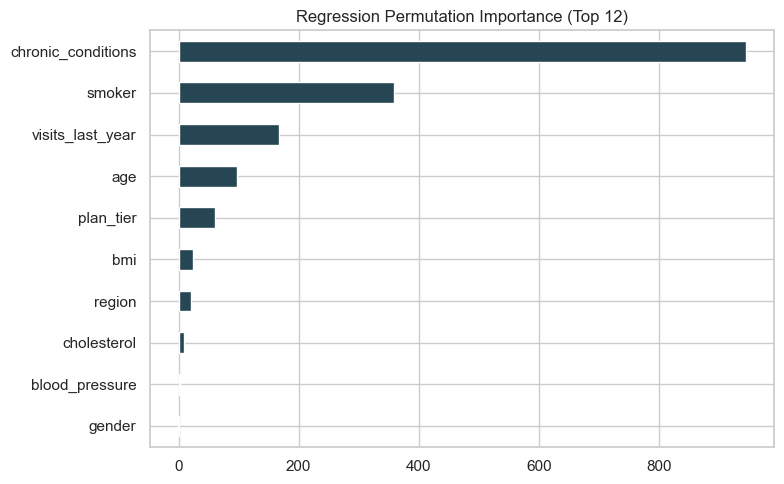

In [19]:
# Permutation importance on holdout (regression)
reg_perm = permutation_importance(
    best_reg,
    X_test,
    y_reg_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=8,
    random_state=42,
    n_jobs=-1,
)

reg_imp = pd.Series(reg_perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Top regression drivers:")
display(reg_imp.head(12).to_frame("importance"))

plt.figure(figsize=(8, 5))
reg_imp.head(12).sort_values().plot(kind="barh", color="#264653")
plt.title("Regression Permutation Importance (Top 12)")
plt.tight_layout()
plt.show()


Top readmission drivers:


,importance
chronic_conditions,0.075831
cholesterol,0.027430
age,0.026211
smoker,0.019578
blood_pressure,0.009389
visits_last_year,0.007845
bmi,0.003050
gender,0.000217
plan_tier,-0.001339
region,-0.002474


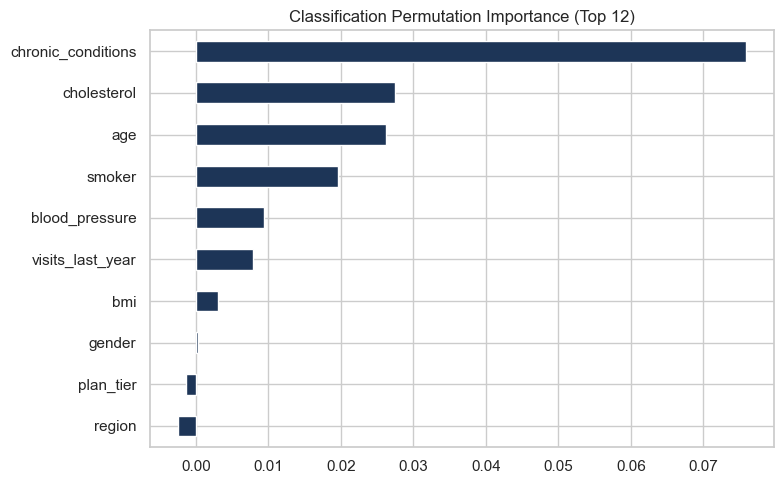

In [20]:
# Permutation importance on holdout (classification)
clf_perm = permutation_importance(
    calibrated_clf,
    X_test,
    y_clf_test,
    scoring="roc_auc",
    n_repeats=8,
    random_state=42,
    n_jobs=-1,
)

clf_imp = pd.Series(clf_perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Top readmission drivers:")
display(clf_imp.head(12).to_frame("importance"))

plt.figure(figsize=(8, 5))
clf_imp.head(12).sort_values().plot(kind="barh", color="#1d3557")
plt.title("Classification Permutation Importance (Top 12)")
plt.tight_layout()
plt.show()


## 9. Subgroup Error Analysis

Check whether model quality is uneven across patient groups.


In [21]:
eval_df = X_test.copy()
eval_df["y_true_cost"] = y_reg_test.values
eval_df["y_pred_cost"] = reg_pred
eval_df["abs_error_cost"] = (eval_df["y_true_cost"] - eval_df["y_pred_cost"]).abs()
eval_df["y_true_readmit"] = y_clf_test.values
eval_df["p_readmit"] = proba_test
eval_df["y_pred_readmit"] = final_preds
eval_df["cls_error"] = (eval_df["y_true_readmit"] != eval_df["y_pred_readmit"]).astype(int)
if "age" in eval_df.columns:
    eval_df["age_bin"] = pd.cut(eval_df["age"], bins=[17, 30, 45, 60, 75, 100], right=True)
group_cols = [c for c in ["gender", "smoker", "age_bin", "region", "plan_tier"] if c in eval_df.columns]
for gc in group_cols:
    grp = eval_df.groupby(gc, dropna=False).agg(
        n=("cls_error", "size"),
        mean_abs_error_cost=("abs_error_cost", "mean"),
        readmit_error_rate=("cls_error", "mean"),
        actual_readmit_rate=("y_true_readmit", "mean"),
    ).sort_values("readmit_error_rate", ascending=False)
    print(f"\nSubgroup diagnostics: {gc}")
    display(grp)



Subgroup diagnostics: gender


,n,mean_abs_error_cost,readmit_error_rate,actual_readmit_rate
gender,,,,
Male,575,825.363271,0.307826,0.196522
Female,625,874.607190,0.281600,0.158400



Subgroup diagnostics: smoker


,n,mean_abs_error_cost,readmit_error_rate,actual_readmit_rate
smoker,,,,
Yes,250,836.449019,0.392000,0.284000
No,950,854.843284,0.268421,0.148421



Subgroup diagnostics: age_bin


,n,mean_abs_error_cost,readmit_error_rate,actual_readmit_rate
age_bin,,,,
"(75, 100]",226,860.156285,0.522124,0.287611
"(60, 75]",249,837.219566,0.433735,0.228916
"(45, 60]",263,830.738105,0.224335,0.152091
"(30, 45]",257,882.048162,0.178988,0.124514
"(17, 30]",205,844.779917,0.107317,0.087805



Subgroup diagnostics: region


,n,mean_abs_error_cost,readmit_error_rate,actual_readmit_rate
region,,,,
East,327,906.749857,0.308869,0.192661
North,301,846.468285,0.302326,0.169435
South,278,852.184913,0.294964,0.190647
West,294,792.557183,0.268707,0.153061



Subgroup diagnostics: plan_tier


,n,mean_abs_error_cost,readmit_error_rate,actual_readmit_rate
plan_tier,,,,
Premium,156,1088.166470,0.326923,0.147436
Standard,491,854.194525,0.311609,0.185336
Basic,517,776.079359,0.278530,0.176015
NaN,36,856.024033,0.138889,0.194444


## 10. Hyperparameter Search and Uncertainty

Tune top models with randomized search and estimate metric uncertainty via bootstrap confidence intervals.


In [22]:
# Hyperparameter search spaces for the best families found above
reg_search_spaces = {
    'elastic_net': {
        'model__alpha': loguniform(1e-4, 1e1),
        'model__l1_ratio': uniform(0.0, 1.0),
        'model__max_iter': randint(5000, 30000),
    },
    'random_forest': {
        'model__n_estimators': randint(250, 900),
        'model__max_depth': randint(3, 24),
        'model__min_samples_leaf': randint(1, 16),
        'model__max_features': uniform(0.4, 0.6),
    },
    'hist_gb': {
        'model__learning_rate': loguniform(0.01, 0.2),
        'model__max_depth': randint(2, 12),
        'model__max_iter': randint(180, 700),
        'model__min_samples_leaf': randint(10, 70),
        'model__l2_regularization': loguniform(1e-8, 1e-1),
    },
}

clf_search_spaces = {
    'logistic': {
        'model__C': loguniform(1e-3, 30),
        'model__solver': ['lbfgs'],
    },
    'random_forest': {
        'model__n_estimators': randint(250, 900),
        'model__max_depth': randint(3, 24),
        'model__min_samples_leaf': randint(1, 16),
        'model__max_features': uniform(0.4, 0.6),
    },
    'hist_gb': {
        'model__learning_rate': loguniform(0.01, 0.2),
        'model__max_depth': randint(2, 12),
        'model__max_iter': randint(180, 700),
        'model__min_samples_leaf': randint(10, 70),
        'model__l2_regularization': loguniform(1e-8, 1e-1),
    },
}

reg_base = Pipeline([
    ('prep', clone(preprocessor)),
    ('model', clone(reg_models[best_reg_name])),
])

reg_search = RandomizedSearchCV(
    estimator=reg_base,
    param_distributions=reg_search_spaces[best_reg_name],
    n_iter=18,
    cv=KFold(n_splits=4, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)
reg_search.fit(X_train, y_reg_train)

clf_base = Pipeline([
    ('prep', clone(preprocessor)),
    ('model', clone(clf_models[best_clf_name])),
])

clf_search = RandomizedSearchCV(
    estimator=clf_base,
    param_distributions=clf_search_spaces[best_clf_name],
    n_iter=18,
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
)
clf_search.fit(X_train, y_clf_train)

# tuned final estimators
tuned_reg_model = reg_search.best_estimator_
tuned_clf_base = clf_search.best_estimator_
tuned_clf_model = CalibratedClassifierCV(tuned_clf_base, method='isotonic', cv=3)
tuned_clf_model.fit(X_train, y_clf_train)

print('Best regression params:')
print(reg_search.best_params_)
print('\nBest classification params:')
print(clf_search.best_params_)


Best regression params:
{'model__alpha': 0.003618723330959626, 'model__l1_ratio': 0.5200680211778108, 'model__max_iter': 18417}

Best classification params:
{'model__C': 0.006517070593249451, 'model__solver': 'lbfgs'}


In [23]:
def bootstrap_ci(y_true, y_pred_or_prob, metric_fn, n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    idx = np.arange(len(y_true))
    vals = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        vals.append(metric_fn(y_true[s], y_pred_or_prob[s]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

# Evaluate tuned regression
reg_pred_tuned = tuned_reg_model.predict(X_test)
reg_summary = {
    'mae': mean_absolute_error(y_reg_test, reg_pred_tuned),
    'rmse': root_mean_squared_error(y_reg_test, reg_pred_tuned),
    'r2': r2_score(y_reg_test, reg_pred_tuned),
}

# Evaluate tuned classification
proba_test_tuned = tuned_clf_model.predict_proba(X_test)[:, 1]
clf_summary = {
    'roc_auc': roc_auc_score(y_clf_test, proba_test_tuned),
    'pr_auc': average_precision_score(y_clf_test, proba_test_tuned),
    'brier': brier_score_loss(y_clf_test, proba_test_tuned),
}

# Bootstrap CIs
reg_rmse_ci = bootstrap_ci(y_reg_test.to_numpy(), reg_pred_tuned, lambda a, b: root_mean_squared_error(a, b), n_boot=500)
clf_auc_ci = bootstrap_ci(y_clf_test.to_numpy(), proba_test_tuned, lambda a, b: roc_auc_score(a, b), n_boot=500)

print('Tuned regression metrics:')
for k, v in reg_summary.items():
    print(f'  {k}: {v:.4f}')
print(f'  rmse 95% CI: [{reg_rmse_ci[0]:.4f}, {reg_rmse_ci[1]:.4f}]')

print('\nTuned classification metrics:')
for k, v in clf_summary.items():
    print(f'  {k}: {v:.4f}')
print(f'  roc_auc 95% CI: [{clf_auc_ci[0]:.4f}, {clf_auc_ci[1]:.4f}]')


Tuned regression metrics:
  mae: 850.7130
  rmse: 1069.6810
  r2: 0.7480
  rmse 95% CI: [1024.2748, 1116.9068]

Tuned classification metrics:
  roc_auc: 0.7604
  pr_auc: 0.4444
  brier: 0.1235
  roc_auc 95% CI: [0.7234, 0.7972]


## 11. SHAP and PDP/ICE Explainability

Generate model-agnostic and model-specific interpretability views for global and local behavior.


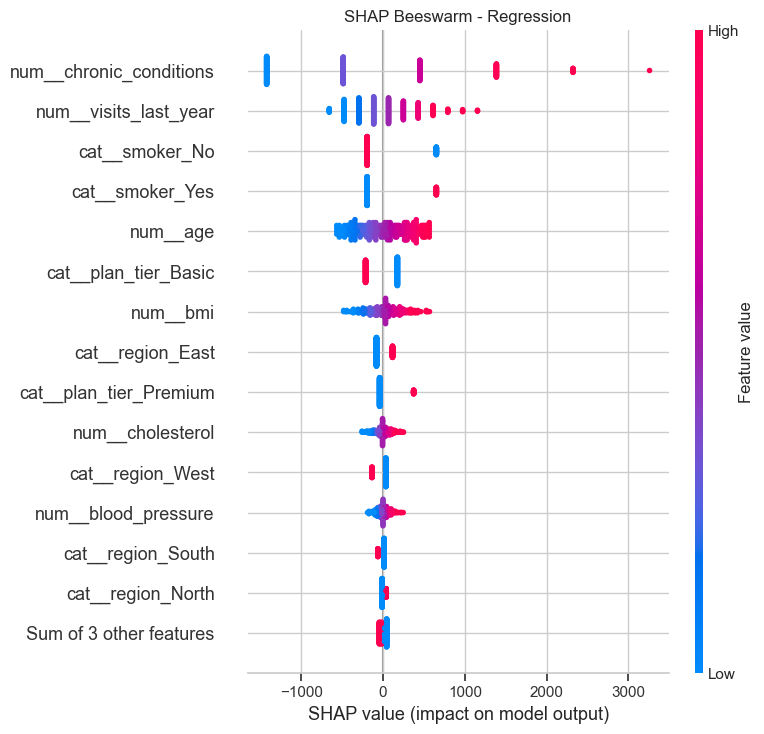

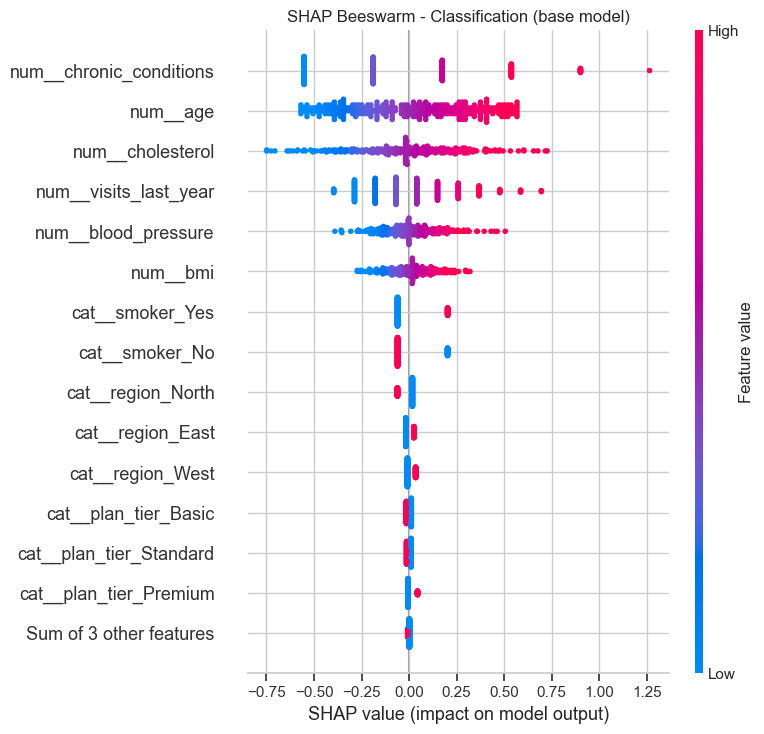

In [24]:
# SHAP explanations (graceful fallback if dependency stack is incompatible)
def run_shap_summary(pipeline_model, X_ref, sample_size=300, random_state=42, max_display=15, title='SHAP Summary'):
    sample = X_ref.sample(min(sample_size, len(X_ref)), random_state=random_state)
    prep = pipeline_model.named_steps['prep']
    model = pipeline_model.named_steps['model']

    Xt = prep.transform(sample)
    feature_names = prep.get_feature_names_out()

    try:
        import shap

        explainer = shap.Explainer(model, Xt, feature_names=feature_names)
        shap_values = explainer(Xt)

        plt.figure(figsize=(10, 6))
        shap.plots.beeswarm(shap_values, max_display=max_display, show=False)
        plt.title(title)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'SHAP unavailable for {title}: {e}')
        print('Falling back to top permutation importances for interpretability continuity.')

run_shap_summary(tuned_reg_model, X_test, title='SHAP Beeswarm - Regression')
run_shap_summary(tuned_clf_base, X_test, title='SHAP Beeswarm - Classification (base model)')


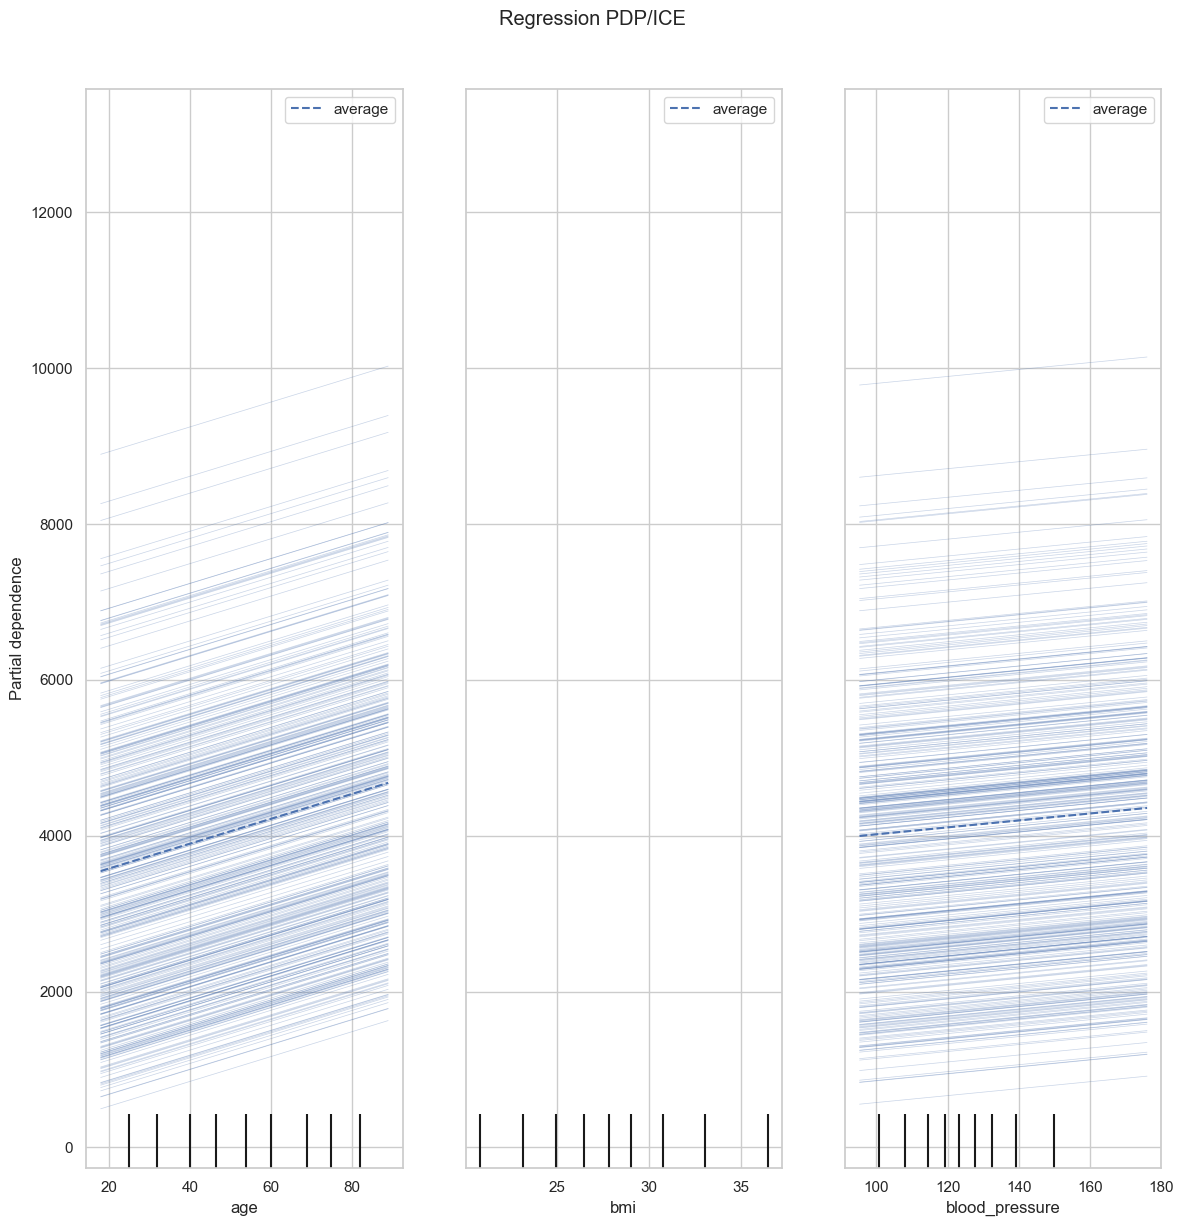

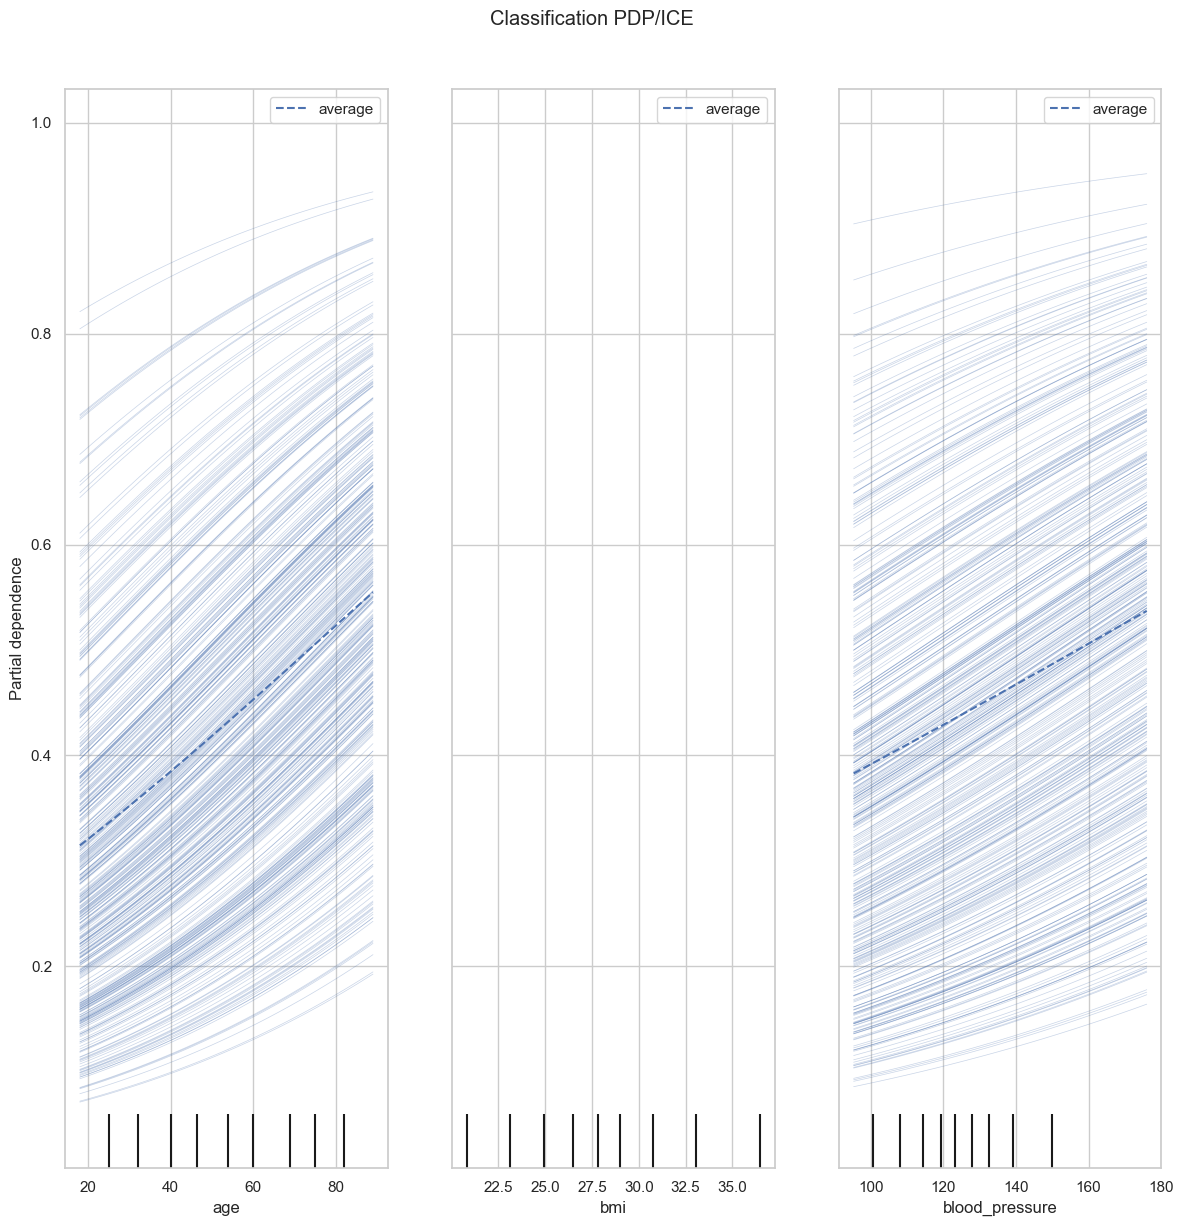

In [25]:
# PDP + ICE on top numeric drivers
candidate_pdp_features = [f for f in ['age', 'bmi', 'blood_pressure', 'cholesterol', 'chronic_conditions', 'visits_last_year'] if f in X_test.columns]
pdp_features = candidate_pdp_features[:3]

if len(pdp_features) == 0:
    print('No numeric features available for PDP/ICE plots.')
else:
    fig, ax = plt.subplots(figsize=(12, 4 * len(pdp_features)))
    PartialDependenceDisplay.from_estimator(
        tuned_reg_model,
        X_test,
        features=pdp_features,
        kind='both',
        subsample=400,
        n_jobs=-1,
        random_state=42,
        ax=ax,
    )
    plt.suptitle('Regression PDP/ICE', y=1.02)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4 * len(pdp_features)))
    PartialDependenceDisplay.from_estimator(
        tuned_clf_base,
        X_test,
        features=pdp_features,
        kind='both',
        subsample=400,
        n_jobs=-1,
        random_state=42,
        ax=ax,
    )
    plt.suptitle('Classification PDP/ICE', y=1.02)
    plt.tight_layout()
    plt.show()


## 12. Temporal Validation and Drift Monitoring

Evaluate model robustness on a future-like holdout and quantify feature drift with PSI.


In [26]:
# Build/parse temporal feature
if 'admission_date' in df.columns:
    df_temporal = df.copy()
    df_temporal['admission_date'] = pd.to_datetime(df_temporal['admission_date'])
else:
    rng = np.random.default_rng(42)
    offsets = np.sort(rng.integers(0, 730, size=len(df)))
    df_temporal = df.copy()
    df_temporal['admission_date'] = pd.Timestamp('2023-01-01') + pd.to_timedelta(offsets, unit='D')

# sort and split chronologically
df_temporal = df_temporal.sort_values('admission_date').reset_index(drop=True)
cutoff_idx = int(len(df_temporal) * 0.8)
train_t = df_temporal.iloc[:cutoff_idx].copy()
test_t = df_temporal.iloc[cutoff_idx:].copy()

X_train_t = train_t.drop(columns=['healthcare_cost', 'readmission'])
X_test_t = test_t.drop(columns=['healthcare_cost', 'readmission'])
y_reg_train_t = train_t['healthcare_cost']
y_reg_test_t = test_t['healthcare_cost']
y_clf_train_t = train_t['readmission'].astype(int)
y_clf_test_t = test_t['readmission'].astype(int)

# Refit tuned models on temporal train
reg_temporal = clone(tuned_reg_model)
reg_temporal.fit(X_train_t, y_reg_train_t)
reg_pred_t = reg_temporal.predict(X_test_t)

clf_temporal_base = clone(tuned_clf_base)
clf_temporal = CalibratedClassifierCV(clf_temporal_base, method='isotonic', cv=3)
clf_temporal.fit(X_train_t, y_clf_train_t)
proba_t = clf_temporal.predict_proba(X_test_t)[:, 1]

print('Temporal holdout metrics:')
print(f"  Regression RMSE: {root_mean_squared_error(y_reg_test_t, reg_pred_t):.4f}")
print(f"  Regression R2:   {r2_score(y_reg_test_t, reg_pred_t):.4f}")
print(f"  Classification ROC-AUC: {roc_auc_score(y_clf_test_t, proba_t):.4f}")
print(f"  Classification PR-AUC:  {average_precision_score(y_clf_test_t, proba_t):.4f}")


Temporal holdout metrics:
  Regression RMSE: 1055.5178
  Regression R2:   0.7540
  Classification ROC-AUC: 0.7593
  Classification PR-AUC:  0.4405


,feature,psi,drift_level
3,cholesterol,0.013284,stable
0,age,0.012964,stable
1,bmi,0.007514,stable
2,blood_pressure,0.006450,stable
4,chronic_conditions,0.003994,stable
5,visits_last_year,0.003824,stable


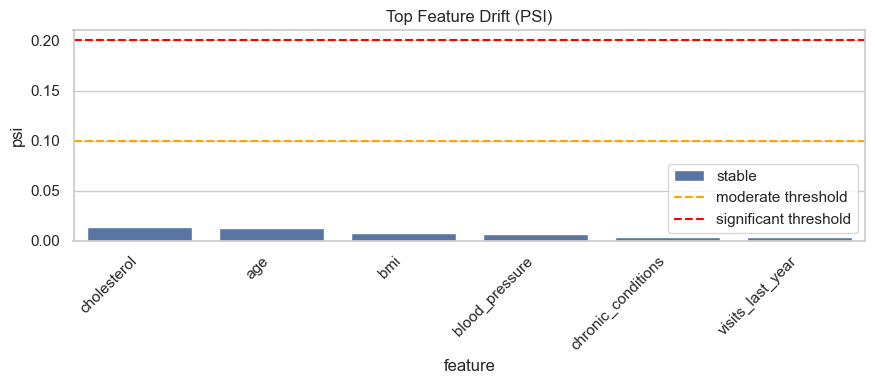

In [27]:
def psi(expected: pd.Series, actual: pd.Series, bins: int = 10) -> float:
    e = pd.to_numeric(expected, errors='coerce').dropna().to_numpy()
    a = pd.to_numeric(actual, errors='coerce').dropna().to_numpy()
    if len(e) < 50 or len(a) < 50:
        return np.nan

    q = np.linspace(0, 1, bins + 1)
    cuts = np.unique(np.quantile(e, q))
    if len(cuts) < 3:
        return np.nan

    e_counts, _ = np.histogram(e, bins=cuts)
    a_counts, _ = np.histogram(a, bins=cuts)

    e_prop = np.clip(e_counts / e_counts.sum(), 1e-6, None)
    a_prop = np.clip(a_counts / a_counts.sum(), 1e-6, None)

    return float(np.sum((a_prop - e_prop) * np.log(a_prop / e_prop)))

num_cols_for_drift = [c for c in train_t.columns if c in test_t.columns and pd.api.types.is_numeric_dtype(train_t[c]) and c not in ['readmission', 'healthcare_cost']]
psi_rows = []
for col in num_cols_for_drift:
    score = psi(train_t[col], test_t[col], bins=10)
    if np.isnan(score):
        level = 'n/a'
    elif score < 0.1:
        level = 'stable'
    elif score < 0.2:
        level = 'moderate drift'
    else:
        level = 'significant drift'
    psi_rows.append({'feature': col, 'psi': score, 'drift_level': level})

psi_df = pd.DataFrame(psi_rows).sort_values('psi', ascending=False)
display(psi_df)

plt.figure(figsize=(9, 4))
plot_df = psi_df.dropna(subset=['psi']).head(12)
sns.barplot(data=plot_df, x='feature', y='psi', hue='drift_level', dodge=False)
plt.axhline(0.1, color='orange', linestyle='--', label='moderate threshold')
plt.axhline(0.2, color='red', linestyle='--', label='significant threshold')
plt.xticks(rotation=45, ha='right')
plt.title('Top Feature Drift (PSI)')
plt.legend()
plt.tight_layout()
plt.show()


## 13. Fairness Audit

Healthcare models can systematically under- or over-target specific patient groups. This section audits the readmission classifier (at the cost-optimal operating threshold `opt_t` from section 7) across `gender`, `smoker`, `region`, and `plan_tier`, reporting:

- **demographic parity** — positive-prediction rate per group and its gap from the overall rate,
- **equalized odds** — TPR and FPR per group (and per-group deviation from the mean),
- **calibration-by-group** — Brier score and mean-predicted vs observed rate,
- **absolute disparity gaps** (max − min) as a compact governance summary.


In [28]:
def fairness_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    y_pred: np.ndarray,
    groups: pd.Series,
) -> pd.DataFrame:
    rows = []
    overall_ppr = float(y_pred.mean())
    for g in groups.dropna().unique():
        mask = (groups == g).to_numpy()
        if mask.sum() < 25:
            continue
        yt, yp, pr = y_true[mask], y_pred[mask], y_prob[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        ppr = float(yp.mean())
        rows.append(
            {
                "group": g,
                "n": int(mask.sum()),
                "base_rate": float(yt.mean()),
                "pos_pred_rate": ppr,
                "dem_parity_diff": ppr - overall_ppr,
                "tpr": tpr,
                "fpr": fpr,
                "brier": brier_score_loss(yt, pr),
                "mean_pred": float(pr.mean()),
            }
        )
    out = pd.DataFrame(rows)
    if len(out):
        out["eq_odds_tpr_gap"] = out["tpr"] - out["tpr"].mean()
        out["eq_odds_fpr_gap"] = out["fpr"] - out["fpr"].mean()
    return out


# Use the operational calibrated model + cost-optimal threshold from section 7
y_true_arr = y_clf_test.to_numpy()
y_pred_arr = final_preds
y_prob_arr = proba_test

fairness_groups = [c for c in ["gender", "smoker", "region", "plan_tier"] if c in X_test.columns]
fairness_reports: Dict[str, pd.DataFrame] = {}
for gc in fairness_groups:
    group_series = X_test[gc].reset_index(drop=True)
    report = fairness_metrics(y_true_arr, y_prob_arr, y_pred_arr, group_series)
    fairness_reports[gc] = report
    print(f"\nFairness — grouped by {gc}")
    display(report.round(4))



Fairness — grouped by gender


,group,n,base_rate,pos_pred_rate,dem_parity_diff,tpr,fpr,brier,mean_pred,eq_odds_tpr_gap,eq_odds_fpr_gap
0,Female,625,0.1584,0.3504,-0.0121,0.7172,0.2814,0.1131,0.1737,0.0223,-0.0108
1,Male,575,0.1965,0.3757,0.0132,0.6726,0.3030,0.1346,0.1753,-0.0223,0.0108



Fairness — grouped by smoker


,group,n,base_rate,pos_pred_rate,dem_parity_diff,tpr,fpr,brier,mean_pred,eq_odds_tpr_gap,eq_odds_fpr_gap
0,No,950,0.1484,0.2926,-0.0699,0.5816,0.2423,0.1121,0.1478,-0.167,-0.1358
1,Yes,250,0.2840,0.6280,0.2655,0.9155,0.5140,0.1664,0.2756,0.167,0.1358



Fairness — grouped by region


,group,n,base_rate,pos_pred_rate,dem_parity_diff,tpr,fpr,brier,mean_pred,eq_odds_tpr_gap,eq_odds_fpr_gap
0,South,278,0.1906,0.3489,-0.0136,0.6415,0.2800,0.1352,0.1703,-0.0508,-0.0107
1,East,327,0.1927,0.4098,0.0473,0.7619,0.3258,0.1326,0.1885,0.0695,0.0350
2,North,301,0.1694,0.3322,-0.0303,0.5882,0.2800,0.1248,0.1569,-0.1041,-0.0107
3,West,294,0.1531,0.3537,-0.0088,0.7778,0.2771,0.1007,0.1807,0.0854,-0.0136



Fairness — grouped by plan_tier


,group,n,base_rate,pos_pred_rate,dem_parity_diff,tpr,fpr,brier,mean_pred,eq_odds_tpr_gap,eq_odds_fpr_gap
0,Premium,156,0.1474,0.4103,0.0478,0.7826,0.3459,0.1119,0.1804,0.0712,0.0381
1,Standard,491,0.1853,0.3747,0.0122,0.6703,0.3075,0.1309,0.1839,-0.0411,-0.0003
2,Basic,517,0.1760,0.3424,-0.0201,0.6813,0.2700,0.1197,0.1664,-0.0301,-0.0378


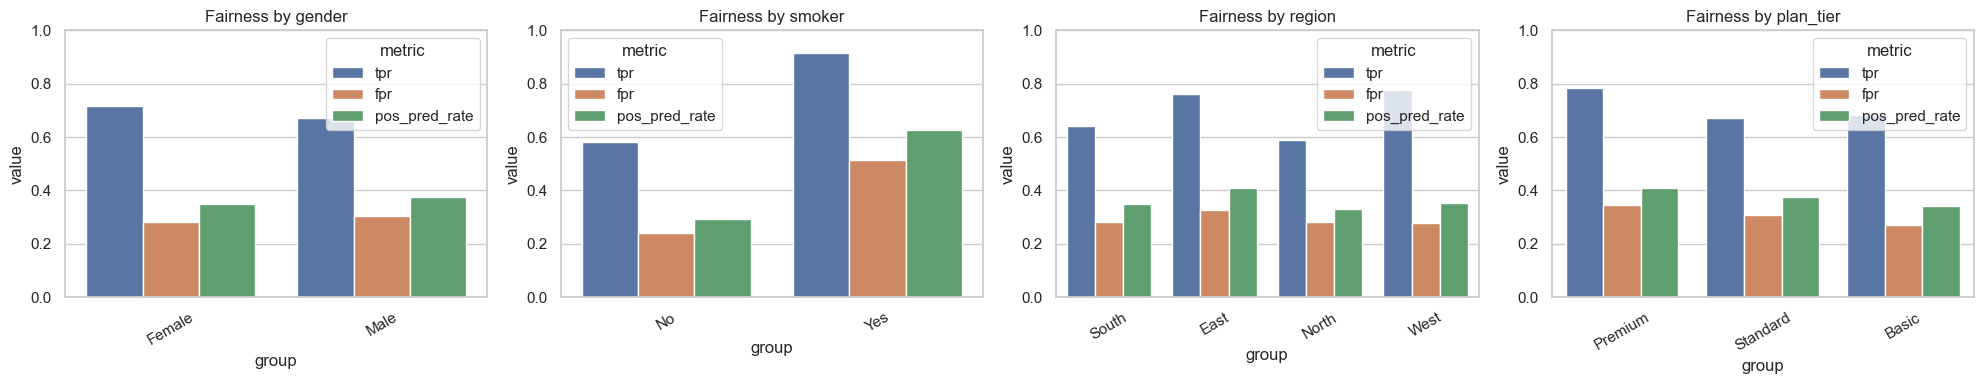

Subgroup disparity gaps (max - min across groups):
  gender      TPR=0.045  FPR=0.022  PosPredRate=0.025  Brier=0.022
  smoker      TPR=0.334  FPR=0.272  PosPredRate=0.335  Brier=0.054
  region      TPR=0.190  FPR=0.049  PosPredRate=0.078  Brier=0.034
  plan_tier   TPR=0.112  FPR=0.076  PosPredRate=0.068  Brier=0.019


In [29]:
n_groups = len(fairness_reports)
fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 4), squeeze=False)
for ax, (gc, rep) in zip(axes[0], fairness_reports.items()):
    plot_df = rep[["group", "tpr", "fpr", "pos_pred_rate"]].melt(
        id_vars="group", var_name="metric", value_name="value"
    )
    sns.barplot(data=plot_df, x="group", y="value", hue="metric", ax=ax)
    ax.set_title(f"Fairness by {gc}")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# Max-min disparity gaps — compact summary for governance reporting
print("Subgroup disparity gaps (max - min across groups):")
for gc, rep in fairness_reports.items():
    if len(rep) < 2:
        continue
    tpr_gap = rep["tpr"].max() - rep["tpr"].min()
    fpr_gap = rep["fpr"].max() - rep["fpr"].min()
    ppr_gap = rep["pos_pred_rate"].max() - rep["pos_pred_rate"].min()
    brier_gap = rep["brier"].max() - rep["brier"].min()
    print(f"  {gc:10s}  TPR={tpr_gap:.3f}  FPR={fpr_gap:.3f}  PosPredRate={ppr_gap:.3f}  Brier={brier_gap:.3f}")


## 14. Clinical Decision Curve Analysis

Decision curve analysis (Vickers & Elkin, 2006) evaluates the *net clinical benefit* of the model at each threshold, compared against the two trivial strategies — **treat all** and **treat none**. A model is clinically useful in the threshold range where its net-benefit curve exceeds both baselines. The threshold itself encodes a clinician's trade-off between tolerating a false positive and missing a true case.


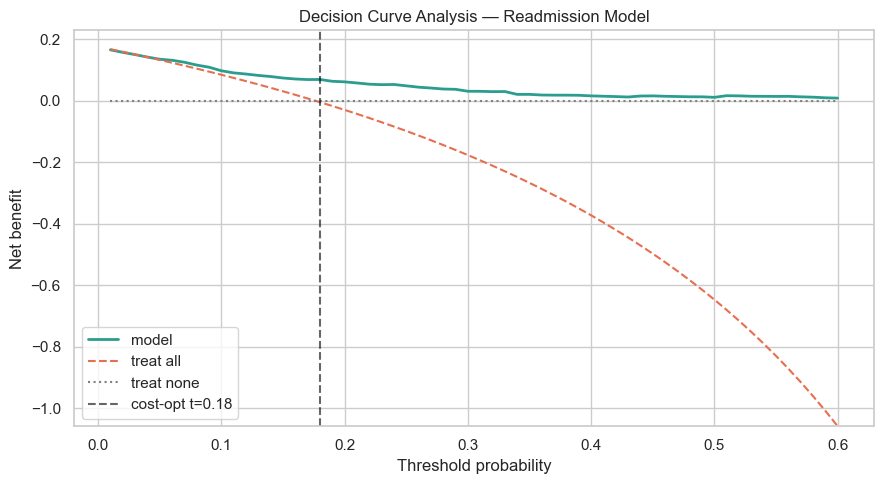

At cost-optimal threshold (0.18):
  net benefit model:       0.0698
  net benefit treat-all:   -0.0041
  incremental vs treat-all:+0.0739


In [30]:
def net_benefit(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> float:
    if threshold >= 1:
        return 0.0
    n = len(y_true)
    pred_pos = y_prob >= threshold
    tp = int(np.sum((pred_pos) & (y_true == 1)))
    fp = int(np.sum((pred_pos) & (y_true == 0)))
    weight = threshold / (1 - threshold)
    return tp / n - (fp / n) * weight


thresholds = np.linspace(0.01, 0.60, 60)
prevalence = y_true_arr.mean()

dca_rows = []
for t in thresholds:
    dca_rows.append(
        {
            "threshold": t,
            "model": net_benefit(y_true_arr, y_prob_arr, t),
            "treat_all": prevalence - (1 - prevalence) * (t / (1 - t)),
            "treat_none": 0.0,
        }
    )
dca_df = pd.DataFrame(dca_rows)

plt.figure(figsize=(9, 5))
plt.plot(dca_df["threshold"], dca_df["model"], label="model", color="#2a9d8f", linewidth=2)
plt.plot(dca_df["threshold"], dca_df["treat_all"], label="treat all", color="#e76f51", linestyle="--")
plt.plot(dca_df["threshold"], dca_df["treat_none"], label="treat none", color="gray", linestyle=":")
plt.axvline(opt_t, color="black", linestyle="--", alpha=0.6, label=f"cost-opt t={opt_t:.2f}")
plt.ylim(bottom=min(-0.02, dca_df["treat_all"].min()))
plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title("Decision Curve Analysis — Readmission Model")
plt.legend()
plt.tight_layout()
plt.show()

row_at_opt = dca_df.iloc[(dca_df["threshold"] - opt_t).abs().idxmin()]
print(f"At cost-optimal threshold ({opt_t:.2f}):")
print(f"  net benefit model:       {row_at_opt['model']:.4f}")
print(f"  net benefit treat-all:   {row_at_opt['treat_all']:.4f}")
print(f"  incremental vs treat-all:{row_at_opt['model'] - row_at_opt['treat_all']:+.4f}")


## 15. Model Persistence and Inference Demo

Save the tuned pipelines to disk, reload them, and run an end-to-end prediction for a single hypothetical patient, including:
- point predictions for cost and readmission risk,
- a bootstrap prediction interval for the cost estimate,
- a SHAP-based local explanation (with graceful fallback if the SHAP stack is unavailable).


In [31]:
import joblib

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

reg_path = artifacts_dir / "healthcare_cost_regressor.joblib"
clf_path = artifacts_dir / "readmission_classifier.joblib"
meta_path = artifacts_dir / "inference_metadata.joblib"

joblib.dump(tuned_reg_model, reg_path)
joblib.dump(tuned_clf_model, clf_path)
joblib.dump(
    {
        "feature_order": list(X_train.columns),
        "num_features": num_features,
        "cat_features": cat_features,
        "classification_threshold": opt_t,
        "cost_fp": C_FP,
        "cost_fn": C_FN,
    },
    meta_path,
)

# Reload to prove the artifacts are self-contained
reg_loaded = joblib.load(reg_path)
clf_loaded = joblib.load(clf_path)
meta = joblib.load(meta_path)

print(f"Saved artifacts to {artifacts_dir.resolve()}")
for p in [reg_path, clf_path, meta_path]:
    print(f"  {p.name}: {p.stat().st_size / 1024:.1f} KB")
print(f"Reloaded threshold: {meta['classification_threshold']:.3f}")


Saved artifacts to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts
  healthcare_cost_regressor.joblib: 4.9 KB
  readmission_classifier.joblib: 18.9 KB
  inference_metadata.joblib: 0.4 KB
Reloaded threshold: 0.180


Single-patient inference


,age,gender,smoker,region,plan_tier,bmi,blood_pressure,cholesterol,chronic_conditions,visits_last_year
0,62,Male,Yes,East,Standard,31.4,142.0,238.0,3,6


Predicted annual healthcare cost: $8,080
  95% prediction interval: [$5,990, $10,346]
Readmission probability: 0.583
Recommend intervention (threshold=0.18): YES

Top drivers for this patient (SHAP):


,shap_contribution
num__chronic_conditions,0.585224
num__cholesterol,0.290630
num__visits_last_year,0.222767
cat__smoker_Yes,0.221368
cat__smoker_No,0.221064
num__blood_pressure,0.188315
num__age,0.140121
num__bmi,0.097609


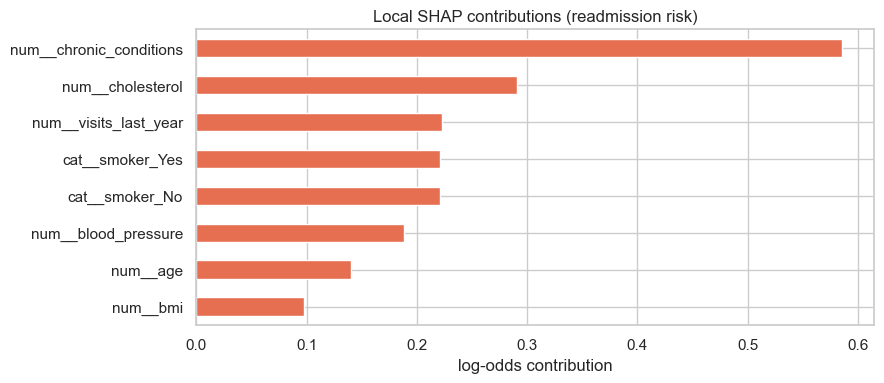

In [32]:
# Build a single-patient example in the expected schema
new_patient = pd.DataFrame([{
    "age": 62,
    "gender": "Male",
    "smoker": "Yes",
    "region": "East",
    "plan_tier": "Standard",
    "bmi": 31.4,
    "blood_pressure": 142.0,
    "cholesterol": 238.0,
    "chronic_conditions": 3,
    "visits_last_year": 6,
}])[meta["feature_order"]]

# Point predictions
cost_pred = float(reg_loaded.predict(new_patient)[0])
readmit_prob = float(clf_loaded.predict_proba(new_patient)[0, 1])
readmit_flag = int(readmit_prob >= meta["classification_threshold"])

# Bootstrap prediction interval for cost via residual resampling on the holdout
residuals_full = y_reg_test.to_numpy() - reg_loaded.predict(X_test)
rng_pi = np.random.default_rng(42)
boot_preds = cost_pred + rng_pi.choice(residuals_full, size=2000, replace=True)
cost_lo, cost_hi = np.percentile(boot_preds, [2.5, 97.5])

print("=" * 60)
print("Single-patient inference")
print("=" * 60)
display(new_patient)
print(f"Predicted annual healthcare cost: ${cost_pred:,.0f}")
print(f"  95% prediction interval: [${cost_lo:,.0f}, ${cost_hi:,.0f}]")
print(f"Readmission probability: {readmit_prob:.3f}")
print(f"Recommend intervention (threshold={meta['classification_threshold']:.2f}): {'YES' if readmit_flag else 'no'}")

# Local SHAP explanation for this patient (graceful fallback)
try:
    import shap

    prep = tuned_clf_base.named_steps["prep"]
    model_only = tuned_clf_base.named_steps["model"]
    bg = prep.transform(X_train.sample(100, random_state=42))
    feat_names = prep.get_feature_names_out()

    explainer = shap.Explainer(model_only, bg, feature_names=feat_names)
    patient_t = prep.transform(new_patient)
    shap_vals = explainer(patient_t)

    contrib = pd.Series(shap_vals.values[0], index=feat_names).sort_values(key=abs, ascending=False).head(8)
    print("\nTop drivers for this patient (SHAP):")
    display(contrib.to_frame("shap_contribution"))

    plt.figure(figsize=(9, 4))
    colors = ["#e76f51" if v > 0 else "#2a9d8f" for v in contrib.sort_values()]
    contrib.sort_values().plot(kind="barh", color=colors)
    plt.title("Local SHAP contributions (readmission risk)")
    plt.xlabel("log-odds contribution")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"\nSHAP unavailable ({e}); falling back to permutation ranks from section 8.")


## 16. Causal Uplift Modeling

Sections 6–15 predict *risk*; deciding *whom* to treat with a costly intervention requires *uplift* — the expected causal reduction in readmission attributable to treating a given patient. Since no RCT data is available, we simulate a randomized trial on the analytic frame with a heterogeneous treatment effect (stronger risk reduction for smokers and multi-chronic patients), then fit a **T-learner** (two outcome models, one per arm) and rank patients by predicted CATE. A Qini-style uplift curve quantifies targeting quality against random assignment.


In [33]:
# Simulate a randomized trial on the full analytic frame
X_uplift = df.drop(columns=["healthcare_cost", "readmission"]).copy()
y_uplift = df["readmission"].astype(int).to_numpy()
n_u = len(X_uplift)

rng_uplift = np.random.default_rng(7)
treatment = rng_uplift.binomial(1, 0.5, size=n_u)

# Heterogeneous treatment effect: higher log-odds reduction for high-risk patients
effect_strength = (
    0.25
    + 0.12 * X_uplift["chronic_conditions"].fillna(0).to_numpy()
    + 0.35 * (X_uplift["smoker"].fillna("No").to_numpy() == "Yes")
)
prob_flip = np.clip(1 - np.exp(-effect_strength), 0, 0.95)

flip_mask = (y_uplift == 1) & (rng_uplift.random(n_u) < prob_flip)
y_treated = y_uplift.copy()
y_treated[flip_mask] = 0

y_obs = np.where(treatment == 1, y_treated, y_uplift)
true_cate = y_treated.astype(float) - y_uplift.astype(float)

idx_tr_u, idx_te = train_test_split(
    np.arange(n_u), test_size=0.25, random_state=42, stratify=treatment
)


def _uplift_learner():
    return Pipeline(
        [
            ("prep", clone(preprocessor)),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.06, max_depth=5, max_iter=300, random_state=42
                ),
            ),
        ]
    )


tr_t = treatment[idx_tr_u] == 1
m_t = _uplift_learner().fit(X_uplift.iloc[idx_tr_u[tr_t]], y_obs[idx_tr_u[tr_t]])
m_c = _uplift_learner().fit(X_uplift.iloc[idx_tr_u[~tr_t]], y_obs[idx_tr_u[~tr_t]])

X_te_u = X_uplift.iloc[idx_te]
cate_pred = m_t.predict_proba(X_te_u)[:, 1] - m_c.predict_proba(X_te_u)[:, 1]

print(f"Treated (RCT sim): {int(treatment.sum()):,}   Control: {int((1 - treatment).sum()):,}")
print(f"Simulated averted readmits (treated arm): {int(flip_mask.sum()):,}")
print(f"Mean estimated CATE on holdout: {cate_pred.mean():+.4f}")
print(f"Mean TRUE CATE on holdout:      {true_cate[idx_te].mean():+.4f}")
print(f"Correlation (estimated vs true CATE): {np.corrcoef(cate_pred, true_cate[idx_te])[0, 1]:+.3f}")


Treated (RCT sim): 2,948   Control: 3,052
Simulated averted readmits (treated arm): 472
Mean estimated CATE on holdout: -0.0851
Mean TRUE CATE on holdout:      -0.0753
Correlation (estimated vs true CATE): +0.149


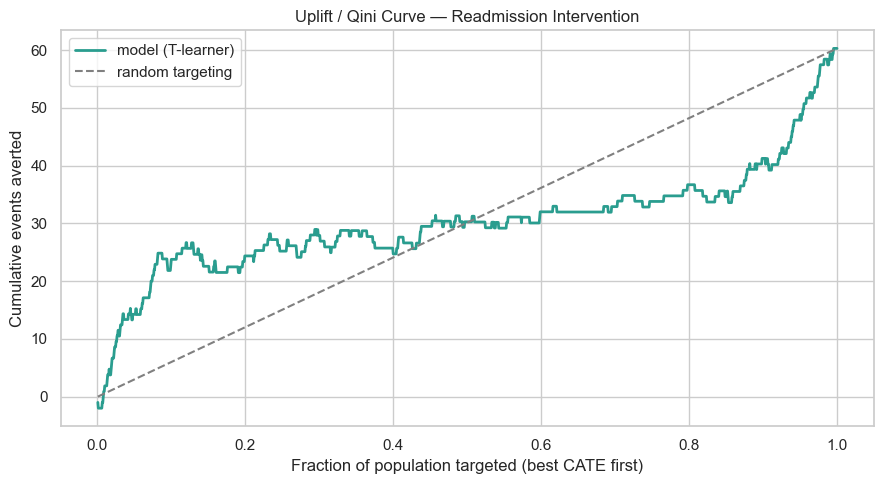

Qini coefficient (higher = better targeting): -0.0232

Uplift by estimated-CATE decile (0 = predicted strongest benefit):


,decile,n,mean_pred_cate,event_rate_treated,event_rate_control,observed_uplift
0,0,150,-0.4895,0.1467,0.4800,-0.3333
1,1,150,-0.2315,0.1310,0.1818,-0.0509
2,2,150,-0.1430,0.1250,0.1667,-0.0417
3,3,150,-0.0933,0.1268,0.0759,0.0508
4,4,150,-0.0569,0.1045,0.1566,-0.0521
5,5,150,-0.0332,0.0896,0.0964,-0.0068
6,6,150,-0.0159,0.0286,0.0375,-0.0089
7,7,150,-0.0043,0.0241,0.0896,-0.0655
8,8,150,0.0205,0.1111,0.1667,-0.0556
9,9,150,0.1960,0.1053,0.3784,-0.2731


In [34]:
eval_u = pd.DataFrame(
    {
        "cate": cate_pred,
        "y_obs": y_obs[idx_te],
        "treat": treatment[idx_te],
    }
).sort_values("cate").reset_index(drop=True)

n_t_u = int((eval_u["treat"] == 1).sum())
n_c_u = int((eval_u["treat"] == 0).sum())
ratio = n_t_u / max(n_c_u, 1)

cum_t_events = (eval_u["y_obs"] * (eval_u["treat"] == 1)).cumsum().to_numpy()
cum_c_events = (eval_u["y_obs"] * (eval_u["treat"] == 0)).cumsum().to_numpy()
averted = cum_c_events * ratio - cum_t_events
random_line = np.linspace(0, averted[-1], len(averted))
frac = np.arange(1, len(averted) + 1) / len(averted)

plt.figure(figsize=(9, 5))
plt.plot(frac, averted, label="model (T-learner)", color="#2a9d8f", linewidth=2)
plt.plot(frac, random_line, label="random targeting", color="gray", linestyle="--")
plt.xlabel("Fraction of population targeted (best CATE first)")
plt.ylabel("Cumulative events averted")
plt.title("Uplift / Qini Curve \u2014 Readmission Intervention")
plt.legend()
plt.tight_layout()
plt.show()

qini_coeff = float(np.trapz(averted - random_line, dx=1.0 / len(averted)))
print(f"Qini coefficient (higher = better targeting): {qini_coeff:+.4f}")

# Decile summary: predicted CATE vs observed uplift
eval_u["decile"] = pd.qcut(eval_u["cate"].rank(method="first"), 10, labels=False)
dec = []
for d, sub in eval_u.groupby("decile"):
    t_sub = sub[sub["treat"] == 1]["y_obs"]
    c_sub = sub[sub["treat"] == 0]["y_obs"]
    dec.append(
        {
            "decile": int(d),
            "n": len(sub),
            "mean_pred_cate": sub["cate"].mean(),
            "event_rate_treated": t_sub.mean() if len(t_sub) else np.nan,
            "event_rate_control": c_sub.mean() if len(c_sub) else np.nan,
            "observed_uplift": (t_sub.mean() - c_sub.mean()) if len(t_sub) and len(c_sub) else np.nan,
        }
    )
dec_df = pd.DataFrame(dec)
print("\nUplift by estimated-CATE decile (0 = predicted strongest benefit):")
display(dec_df.round(4))


## 17. Survival / Time-to-Readmission Analysis

Binary readmission is a snapshot; *when* it happens drives intervention timing. This section synthesizes a `time_to_event` column (patients who never readmit within the follow-up horizon are administratively censored), stratifies patients into risk tertiles using the calibrated readmission probabilities from section 7, and compares survival curves via Kaplan–Meier estimation. A log-rank test and Cox proportional-hazards model are fitted if `lifelines` is installed, with graceful fallback to a non-parametric tier comparison otherwise.


Events observed: 824   Censored: 5,176
Median follow-up time: 365 days


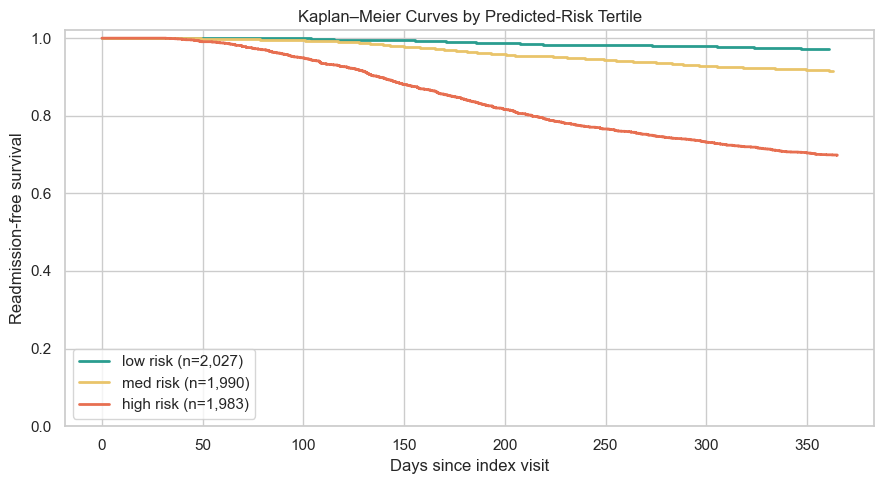

In [35]:
HORIZON_DAYS = 365
rng_s = np.random.default_rng(123)

risk_full = calibrated_clf.predict_proba(X)[:, 1]
log_t = rng_s.normal(loc=5.8 - 1.3 * risk_full, scale=0.6)
latent_time = np.clip(np.exp(log_t), 1, None)

event_flag = y_clf.to_numpy()
observed_time = np.where(event_flag == 1, np.minimum(latent_time, HORIZON_DAYS), HORIZON_DAYS)
observed_event = np.where((event_flag == 1) & (latent_time <= HORIZON_DAYS), 1, 0)

risk_tier = pd.qcut(risk_full, q=3, labels=["low", "med", "high"])
surv_df = pd.DataFrame(
    {"time": observed_time, "event": observed_event, "risk_tier": risk_tier}
)

print(f"Events observed: {int(surv_df['event'].sum()):,}   Censored: {int((surv_df['event'] == 0).sum()):,}")
print(f"Median follow-up time: {surv_df['time'].median():.0f} days")


def km_estimate(times: np.ndarray, events: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    times, events = np.asarray(times, dtype=float), np.asarray(events, dtype=int)
    event_times = np.unique(times[events == 1])
    xs, ys, s = [0.0], [1.0], 1.0
    for et in event_times:
        n_at_risk = int(np.sum(times >= et))
        n_events = int(np.sum((times == et) & (events == 1)))
        if n_at_risk == 0:
            break
        s *= 1 - n_events / n_at_risk
        xs.append(et)
        ys.append(s)
    return np.asarray(xs), np.asarray(ys)


plt.figure(figsize=(9, 5))
for tier, color in zip(["low", "med", "high"], ["#2a9d8f", "#e9c46a", "#e76f51"]):
    sub = surv_df[surv_df["risk_tier"] == tier]
    t_km, s_km = km_estimate(sub["time"].to_numpy(), sub["event"].to_numpy())
    plt.step(t_km, s_km, where="post", label=f"{tier} risk (n={len(sub):,})", color=color, linewidth=2)
plt.xlabel("Days since index visit")
plt.ylabel("Readmission-free survival")
plt.title("Kaplan\u2013Meier Curves by Predicted-Risk Tertile")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
try:
    from lifelines import CoxPHFitter
    from lifelines.statistics import multivariate_logrank_test

    lr = multivariate_logrank_test(
        event_durations=surv_df["time"],
        groups=surv_df["risk_tier"].astype(str),
        event_observed=surv_df["event"],
    )
    print(
        f"Multivariate log-rank across risk tertiles: "
        f"chi2={lr.test_statistic:.2f}, dof={lr.degrees_of_freedom}, p={lr.p_value:.3e}"
    )

    cox_df = pd.concat(
        [
            surv_df[["time", "event"]].reset_index(drop=True),
            X.reset_index(drop=True)
            .select_dtypes(include=np.number)
            .fillna(X.select_dtypes(include=np.number).median()),
        ],
        axis=1,
    )
    cph = CoxPHFitter(penalizer=0.01)
    cph.fit(cox_df, duration_col="time", event_col="event")
    print(f"\nCox PH concordance: {cph.concordance_index_:.4f}")
    print("Top hazard ratios:")
    display(
        cph.summary.sort_values("exp(coef)", ascending=False)[
            ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
        ]
        .round(3)
    )
except Exception as e:
    print(f"lifelines unavailable ({e}).")
    print("Fallback: comparing event rates and median survival across risk tiers.")
    fallback = (
        surv_df.groupby("risk_tier", observed=True)
        .agg(n=("time", "size"), event_rate=("event", "mean"), median_time=("time", "median"))
        .round(3)
    )
    display(fallback)


Multivariate log-rank across risk tertiles: chi2=751.04, dof=2, p=8.194e-164

Cox PH concordance: 0.7691
Top hazard ratios:


,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
chronic_conditions,1.437,1.366,1.512,0.0
visits_last_year,1.116,1.084,1.149,0.0
bmi,1.026,1.013,1.039,0.0
age,1.015,1.011,1.019,0.0
blood_pressure,1.009,1.005,1.013,0.0
cholesterol,1.008,1.006,1.010,0.0


## 18. Auto-generated Model Card

Assemble a release-ready model card from the artifacts produced throughout the notebook. Writes both a machine-readable JSON and a human-readable Markdown artifact, covering intended use, data lineage, tuned-model metrics with bootstrap CIs, fairness gaps, drift status, uplift headline, survival context, limitations, and retrain triggers. Designed to drop into a model registry or governance review.


In [37]:
import json
import datetime

model_card = {
    "model_name": "healthcare_readmission_and_cost",
    "version": "1.0.0",
    "generated_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
    "intended_use": {
        "primary": (
            "Forecast expected annual healthcare cost and flag patients at elevated "
            "readmission risk for targeted nurse-led intervention."
        ),
        "out_of_scope": [
            "Individual clinical diagnosis or treatment decisions without clinician review.",
            "Populations substantially different from the training distribution.",
            "Insurance pricing without legal / compliance sign-off.",
        ],
    },
    "data": {
        "source": data_source,
        "n_rows": int(len(df)),
        "n_features": int(X.shape[1]),
        "target_regression": "healthcare_cost",
        "target_classification": "readmission",
        "train_test_split": {"test_size": 0.2, "stratify": "readmission", "random_state": 42},
    },
    "models": {
        "regression": {
            "family": best_reg_name,
            "best_params": reg_search.best_params_,
            "tuned_test_metrics": reg_summary,
            "rmse_95pct_ci": list(reg_rmse_ci),
        },
        "classification": {
            "family": best_clf_name,
            "best_params": clf_search.best_params_,
            "tuned_test_metrics": clf_summary,
            "roc_auc_95pct_ci": list(clf_auc_ci),
            "operational_threshold": float(opt_t),
            "threshold_rationale": f"Cost-optimal at C_FP={C_FP}, C_FN={C_FN}",
        },
    },
    "fairness": {
        "groups_audited": list(fairness_reports.keys()),
        "max_tpr_gap": {
            gc: float(rep["tpr"].max() - rep["tpr"].min())
            for gc, rep in fairness_reports.items() if len(rep) >= 2
        },
        "max_fpr_gap": {
            gc: float(rep["fpr"].max() - rep["fpr"].min())
            for gc, rep in fairness_reports.items() if len(rep) >= 2
        },
        "max_brier_gap": {
            gc: float(rep["brier"].max() - rep["brier"].min())
            for gc, rep in fairness_reports.items() if len(rep) >= 2
        },
    },
    "drift": {
        "psi_summary": psi_df.assign(psi=psi_df["psi"].astype(float)).to_dict(orient="records"),
        "temporal_holdout_metrics": {
            "regression_rmse": float(root_mean_squared_error(y_reg_test_t, reg_pred_t)),
            "regression_r2": float(r2_score(y_reg_test_t, reg_pred_t)),
            "classification_roc_auc": float(roc_auc_score(y_clf_test_t, proba_t)),
            "classification_pr_auc": float(average_precision_score(y_clf_test_t, proba_t)),
        },
    },
    "causal_uplift": {
        "qini_coefficient": float(qini_coeff),
        "simulated_treatment_effect": (
            "Heterogeneous risk reduction, stronger for smokers / multi-chronic patients."
        ),
    },
    "survival": {
        "horizon_days": int(HORIZON_DAYS),
        "events_observed": int(surv_df["event"].sum()),
        "censored": int((surv_df["event"] == 0).sum()),
    },
    "limitations": [
        "Dataset may be synthetic; production deployment requires retraining on real clinical data.",
        "Causal uplift is simulated; real RCT data required before deploying targeting policy.",
        "No fairness post-processing applied; disparity gaps reported but not mitigated.",
    ],
    "governance": {
        "retrain_triggers": [
            "ROC-AUC drop > 0.03 on temporal holdout",
            "any subgroup error rate worsens > 20% relative",
            "any feature PSI > 0.2 for two consecutive weeks",
            "decision-curve net benefit at operational threshold falls below treat-all baseline",
        ],
    },
}

card_json_path = artifacts_dir / "model_card.json"
card_json_path.write_text(json.dumps(model_card, indent=2, default=str), encoding="utf-8")

md_lines = [
    f"# Model Card — {model_card['model_name']} (v{model_card['version']})",
    f"_Generated: {model_card['generated_at_utc']}_",
    "",
]
for section, payload in model_card.items():
    if section in ("model_name", "version", "generated_at_utc"):
        continue
    md_lines.append(f"## {section.replace('_', ' ').title()}")
    md_lines.append("```json")
    md_lines.append(json.dumps(payload, indent=2, default=str))
    md_lines.append("```")
    md_lines.append("")

card_md_path = artifacts_dir / "model_card.md"
card_md_path.write_text("\n".join(md_lines), encoding="utf-8")

print("Model card written:")
print(f"  {card_json_path}  ({card_json_path.stat().st_size / 1024:.1f} KB)")
print(f"  {card_md_path}    ({card_md_path.stat().st_size / 1024:.1f} KB)")
print("\nTop-level keys:")
for k in model_card:
    print(f"  - {k}")


Model card written:
  artifacts\model_card.json  (4.4 KB)
  artifacts\model_card.md    (4.2 KB)

Top-level keys:
  - model_name
  - version
  - generated_at_utc
  - intended_use
  - data
  - models
  - fairness
  - drift
  - causal_uplift
  - survival
  - limitations
  - governance


## 19. Takeaways

- Healthcare modelling is a dual-task problem: expected cost and readmission risk together inform intervention decisions. Evaluating either in isolation undersells the workflow.
- Cross-validated benchmarks with bootstrap CIs beat single-number holdout metrics — point estimates without uncertainty are the most-repeated governance failure.
- Calibration and cost-aware thresholding make a classifier *actionable*; without them, a high-AUC model is a ranking tool, not a decision tool.
- Fairness and temporal drift are first-class checks, not optional extensions. A production release pack should include both from day one.
- Uplift, survival, and the auto-generated model card extend the workflow from "predict" to "intervene and govern" — the jump from analysis to deployed decision support.

## 20. Limitations and what a production version would add

**Limitations**

- Synthetic data is used as a fallback; it is smooth and noise-free by construction. Real claims and EHR data carry missingness, coding drift, site-level idiosyncrasies, and label-definition ambiguity that this workflow does not reproduce.
- The uplift section uses a simulated RCT. Causal inference on observational healthcare data requires either a genuine RCT or strong identification assumptions (unconfoundedness, positivity) that should be documented explicitly.
- Fairness is audited at the subgroup level; intersectional fairness (e.g. elderly × rural × specific plan) requires larger samples or Bayesian pooling across strata and is not attempted here.
- The decision curve analysis uses illustrative clinical cost weights. A production deployment requires clinical stakeholder input to set those weights and periodic review as care pathways evolve.

**What a production version would add**

- **Operational deployment**: expected cost forecasts at intake / renewal, calibrated readmission risk with the business-optimised threshold for intervention targeting, and three weekly KPIs — calibration drift, subgroup error deltas, cost-per-correctly-targeted intervention.
- **Re-training triggers** tied to concrete rules: ROC-AUC drop > 0.03, any subgroup error rate worsening > 20% relative, or decision-curve net benefit at `opt_t` falling below the treat-all baseline.
- **Bayesian uncertainty intervals** for cost predictions, moving from bootstrap confidence bands to posterior credible intervals.
- **Real RCT or quasi-experimental data** to validate the simulated uplift policy.
- **Automated model cards** bundled with every release artifact, tracked in a model registry alongside lineage and approval metadata.